# **Fase de entendimiento del negocio**

# Objetivo
Identificar aquellos vuelos que van a demorarse para ofrecer beneficios a clientes afectados.
Segun el nivel de cada cliente, se le otorgara un beneficio diferente, siempre teniendo en cuenta que el fin es **Reducir costos**

## Variables objetivo
- Vuelo demorado (1- Demorado | 0- No demorado)
- Beneficio otorgado


# **Fase de entendimiento de los datos**

## Analisis exploratorio de los datos (Excel vuelos)

### Import de librerias

In [ ]:
import pandas as pd
# Importamos la función train_test_split de sklearn.model_selection
# para dividir nuestros datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importamos el StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador KNN de sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier

#Seaborn para graficos
import seaborn as sns

# Importamos las funciones classification_report y confusion_matrix
# de sklearn.metrics para evaluar la precisión del modelo y
# para visualizar los resultados de la clasificación
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree


### Lectura del excel

In [ ]:
df = pd.read_excel('/content/Vuelos.xlsx')

### Previsualizacion

In [ ]:
df.head(100)

,id_vuelo,aeropuerto_origen,aeropuerto_destino,hora_salida_programada,dia_semana,distancia_vuelo,condiciones_climaticas,congestion_aerea,tipo_avion,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
0,10002,GIG,GRU,09:30,Miércoles,360,Despejado,Baja,Boeing 737,52.8,False,45,12.2,57,1
1,10003,TUC,EZE,11:00,Sábado,1230,Despejado,Alta,Embraer E195,54.4,True,11,10.7,132,1
2,10005,MEX,PTY,08:15,Viernes,2280,Niebla,Media,Boeing 757,48.7,True,7,1.0,199,0
3,10006,POA,GRU,06:45,Martes,1110,Despejado,Baja,Airbus A320neo,68.0,False,15,15.8,109,1
4,10008,PTY,EZE,11:30,Domingo,5100,Despejado,Baja,Airbus A330,92.0,True,36,23.0,421,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10130,CWB,GRU,08:30,Domingo,410,Nublado,Media,ATR 72,54.3,False,49,9.7,60,0
96,10132,EZE,MDZ,06:45,Viernes,1040,Lluvia,Media,Boeing 737 MAX,60.1,True,3,27.7,113,0
97,10133,CLO,BOG,09:30,Viernes,300,Nublado,Baja,ATR 72,74.9,False,37,16.5,50,0
98,10134,MDE,CLO,08:30,Jueves,265,Despejado,Alta,Boeing 737,39.1,False,9,24.8,59,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_vuelo                15000 non-null  int64  
 1   aeropuerto_origen       15000 non-null  object 
 2   aeropuerto_destino      15000 non-null  object 
 3   hora_salida_programada  15000 non-null  object 
 4   dia_semana              15000 non-null  object 
 5   distancia_vuelo         15000 non-null  int64  
 6   condiciones_climaticas  15000 non-null  object 
 7   congestion_aerea        15000 non-null  object 
 8   tipo_avion              15000 non-null  object 
 9   ocupacion_vuelo         15000 non-null  float64
 10  temporada_alta          15000 non-null  bool   
 11  puerta_embarque         15000 non-null  int64  
 12  visibilidad             15000 non-null  float64
 13  tiempo_estimado_vuelo   15000 non-null  int64  
 14  demora                  15000 non-null

Podemos visualizar que no hay valor nulos en los datos de las columnas

In [ ]:
df.describe()

,id_vuelo,distancia_vuelo,ocupacion_vuelo,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
count,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,20011.42920,1811.709667,71.383327,25.052200,15.371927,169.874467,0.318533
std,5791.68528,2276.650883,15.964749,14.130638,8.633404,171.010583,0.465923
min,10002.00000,35.000000,9.200000,1.000000,0.200000,22.000000,0.000000
25%,14993.75000,300.000000,61.100000,13.000000,8.100000,58.000000,0.000000
50%,20029.50000,960.000000,73.400000,25.000000,15.600000,103.000000,0.000000
75%,25041.25000,2620.000000,83.800000,37.000000,22.900000,220.000000,1.000000
max,30000.00000,10050.000000,99.800000,49.000000,30.000000,802.000000,1.000000


In [ ]:
df.corr(numeric_only=True)

,id_vuelo,distancia_vuelo,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
id_vuelo,1.000000,-0.001020,0.012959,-0.012732,0.001371,-0.003046,-0.001378,0.017022
distancia_vuelo,-0.001020,1.000000,0.009143,0.015737,-0.012150,0.008574,0.998735,0.008190
ocupacion_vuelo,0.012959,0.009143,1.000000,0.006436,0.006495,0.013661,0.009361,0.014905
temporada_alta,-0.012732,0.015737,0.006436,1.000000,0.015512,0.005241,0.016354,0.099031
puerta_embarque,0.001371,-0.012150,0.006495,0.015512,1.000000,0.003345,-0.011913,-0.000075
visibilidad,-0.003046,0.008574,0.013661,0.005241,0.003345,1.000000,0.008555,-0.127020
tiempo_estimado_vuelo,-0.001378,0.998735,0.009361,0.016354,-0.011913,0.008555,1.000000,0.007885
demora,0.017022,0.008190,0.014905,0.099031,-0.000075,-0.127020,0.007885,1.000000


Podemos visualizar que hay una correlacion lineal de 0.99 con el tiempo_estimado_vuelo y distancia_vuelo

In [ ]:
# Cuenta la cantidad de cada clase
print("Conteo de clases:")
print(df['demora'].value_counts())

# Muestra el porcentaje (proporción)
print("\nProporción de clases:")
print(df['demora'].value_counts(normalize=True) * 100)

Conteo de clases:
demora
0    10222
1     4778
Name: count, dtype: int64

Proporción de clases:
demora
0    68.146667
1    31.853333
Name: proportion, dtype: float64


Graficos para la visualizacion de relacion entre variables

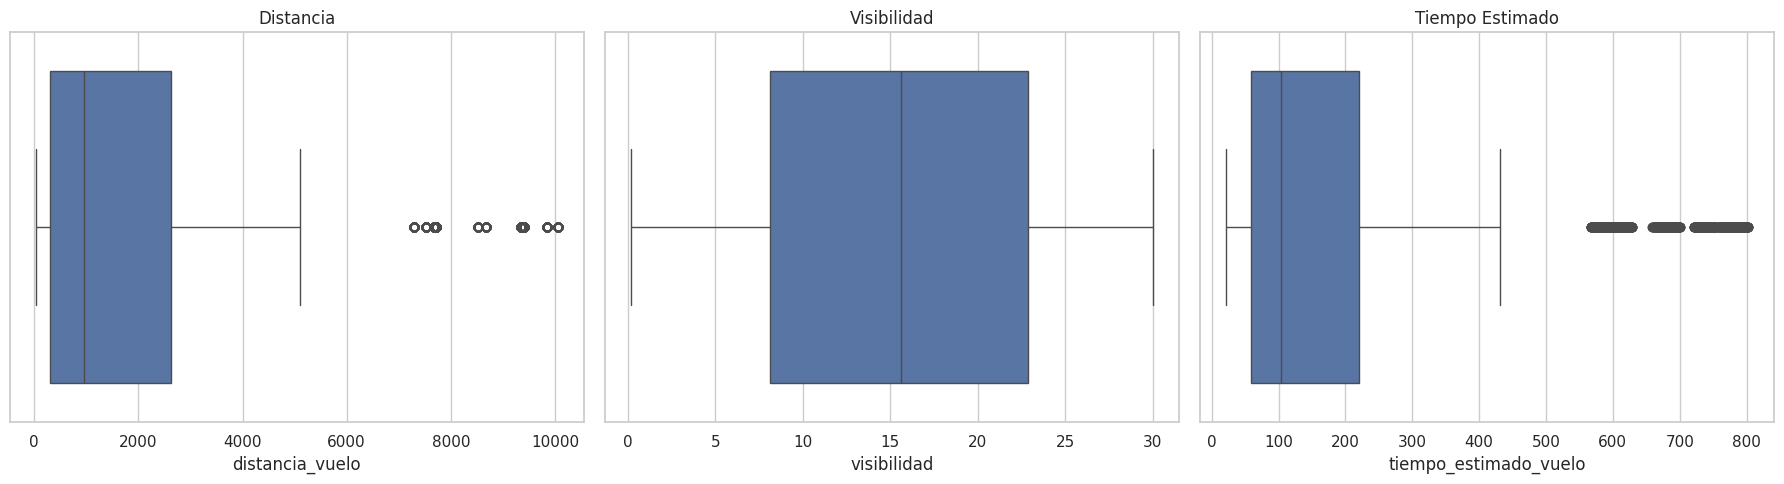

In [ ]:
# Creamos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graficamos cada uno en su lugar (usando el argumento 'ax')
sns.boxplot(x=df['distancia_vuelo'], ax=axes[0])
axes[0].set_title('Distancia')

sns.boxplot(x=df['visibilidad'], ax=axes[1])
axes[1].set_title('Visibilidad')

sns.boxplot(x=df['tiempo_estimado_vuelo'], ax=axes[2])
axes[2].set_title('Tiempo Estimado')


plt.tight_layout() # Para que no se encimen los textos
plt.show()

Podemos visualizar que visibilidad no posee outliers y esta contenido entre 7 a 23 aproximadamente.

Por otro lado Distancia tiene algunas distancias muy largas asi como tiempo estimado valores muy altos, realizamos un scatterplot para verificar si hay relacion entre estos valores y verificar que sean correctos.

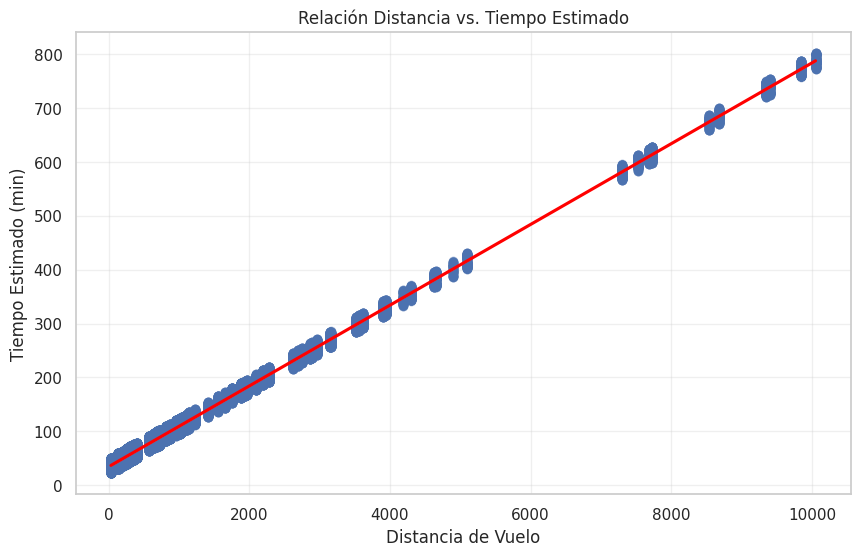

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos regplot para ver la línea de tendencia central
sns.regplot(x='distancia_vuelo', y='tiempo_estimado_vuelo', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relación Distancia vs. Tiempo Estimado')
plt.xlabel('Distancia de Vuelo')
plt.ylabel('Tiempo Estimado (min)')
plt.grid(True, alpha=0.3)
plt.show()

Confirmamos la correlacion lineal de tiempo estimado de vuelo y la distancia de vuelo, y que las mismas no infieren en la demora.

### Graficos para visualizar relacion de demora segun modelo de avion - condicion climatica

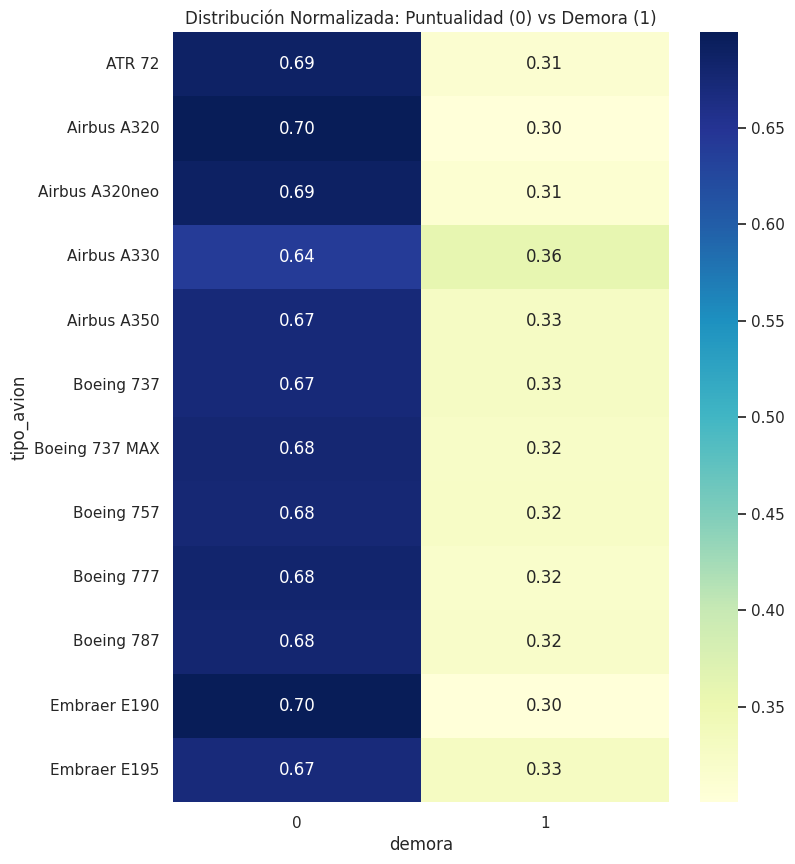

In [ ]:
tabla_contingencia = pd.crosstab(df['tipo_avion'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_contingencia, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

El heatmap nos permite visualizar que hay una proporcion similar de puntualidad y demora para todos los aviones, por lo tanto, esta variable no tendria inferencia en las demoras y puede ser eliminada.
Procedemos a realizar un heatmap para las condiciones del clima

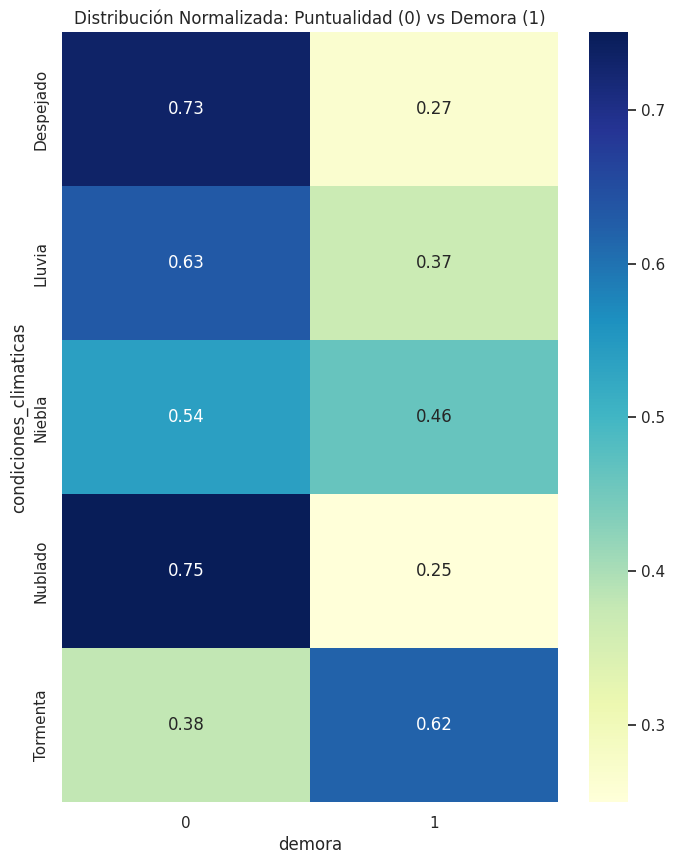

In [ ]:
tabla_clima = pd.crosstab(df['condiciones_climaticas'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_clima, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

Identificamos que hay mayores probabilidades de que haya una demora en casos de tormenta y niebla (en menor medida)
Por lo tanto, las condicioens climaticas son de importancia para la demora y no debe ser imputada.

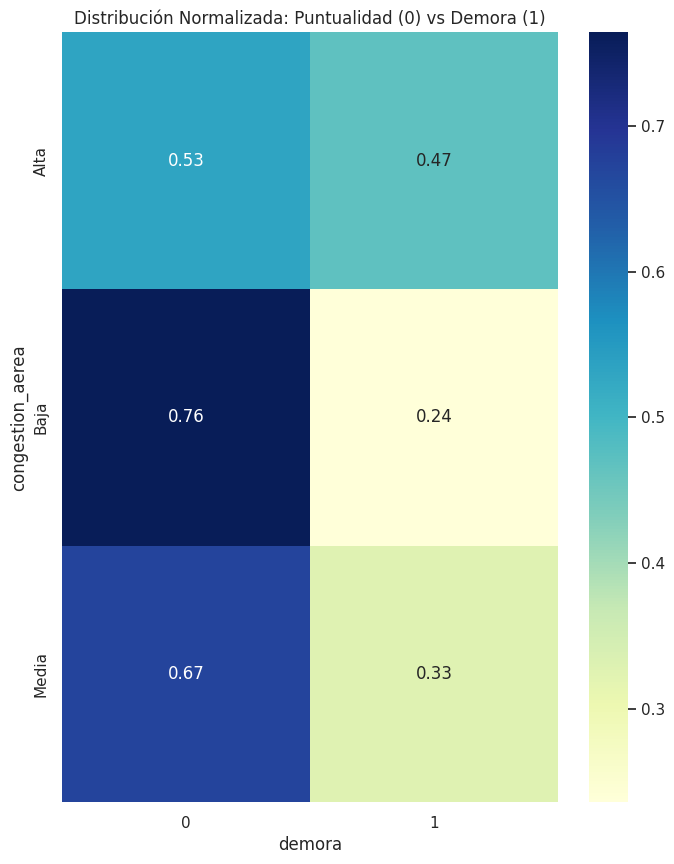

In [ ]:
tabla_congestion = pd.crosstab(df['congestion_aerea'], df['demora'], normalize='index')

plt.figure(figsize=(8, 10))
sns.heatmap(tabla_congestion, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

Se puede visualizar que con el aumento de la congestion aerea, existen mayores casos de demora, por lo tanto es una columna a tener en cuenta y no debe ser imputada

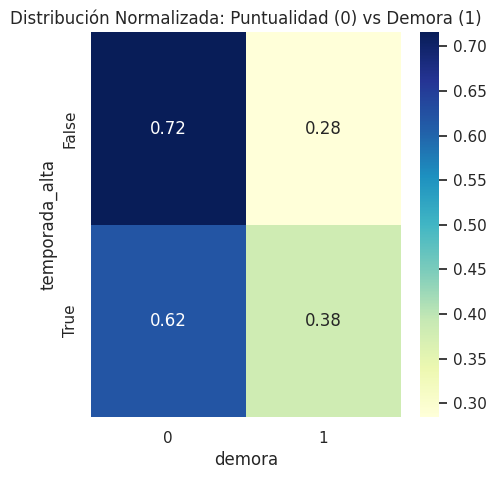

In [ ]:
tabla_temporada = pd.crosstab(df['temporada_alta'], df['demora'], normalize='index')

plt.figure(figsize=(5, 5))
sns.heatmap(tabla_temporada, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()



Se obtiene una mayor demora en casos de temporada alta, pero es tan solo un 0.10 de mejora, podria considerarse como una diferencia marginal.

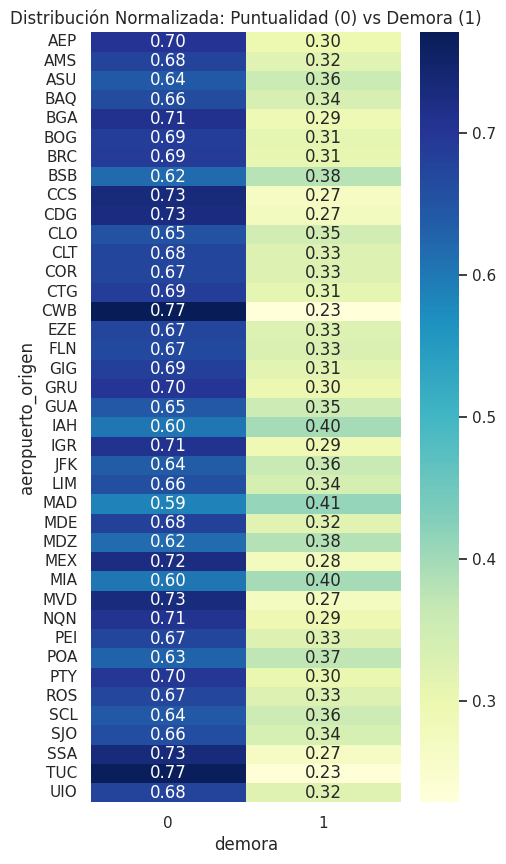

In [ ]:
tabla_orign = pd.crosstab(df['aeropuerto_origen'], df['demora'], normalize='index')

plt.figure(figsize=(5, 10))
sns.heatmap(tabla_orign, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Distribución Normalizada: Puntualidad (0) vs Demora (1)')
plt.show()

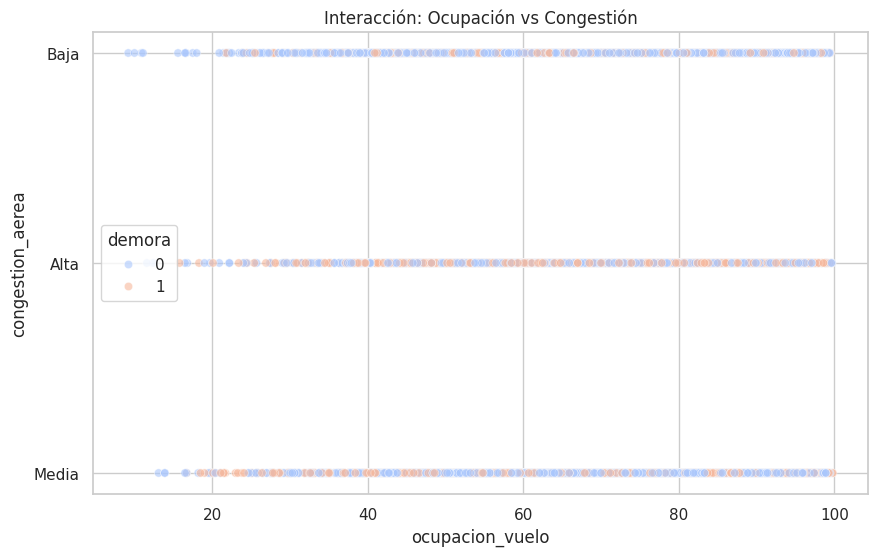

In [ ]:
plt.figure(figsize=(10, 6))
# Gráfico de dispersión coloreado por demora
sns.scatterplot(x='ocupacion_vuelo', y='congestion_aerea', hue='demora',
                data=df, alpha=0.6, palette='coolwarm')

plt.title('Interacción: Ocupación vs Congestión')
plt.show()

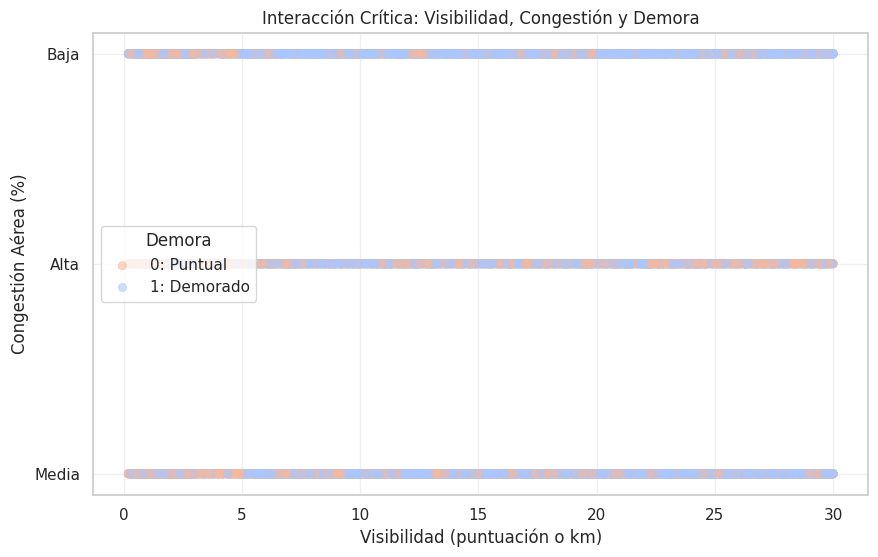

In [ ]:
### Congestion aerea vs visiblidad para identificar relacion x demora

# Seteamos un estilo limpio
sns.set_theme(style="whitegrid")

# Creamos el gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(10, 6))

# Usamos color (hue) para separar Demora=1 de Demora=0
scatter = sns.scatterplot(
    x='visibilidad',
    y='congestion_aerea',
    hue='demora',
    data=df,
    palette='coolwarm', # Colores claros: azul para puntual, rojo para demora
    alpha=0.6,          # Transparencia para ver puntos encimados (overplotting)
    edgecolor=None      # Sin borde para limpiar el gráfico
)

# Personalización
plt.title('Interacción Crítica: Visibilidad, Congestión y Demora')
plt.xlabel('Visibilidad (puntuación o km)')
plt.ylabel('Congestión Aérea (%)')
plt.grid(True, alpha=0.3)

# Mejoramos la leyenda para que sea clara
plt.legend(title='Demora', labels=['0: Puntual', '1: Demorado'])

plt.show()

Se identificó que la Visibilidad actúa como una condición necesaria pero no suficiente para la puntualidad: si es baja, la demora es casi segura. Sin embargo, en condiciones de buena visibilidad, la Congestión Aérea emerge como el principal driver de retrasos, demostrando que el sistema es vulnerable tanto a factores climáticos como operativos.

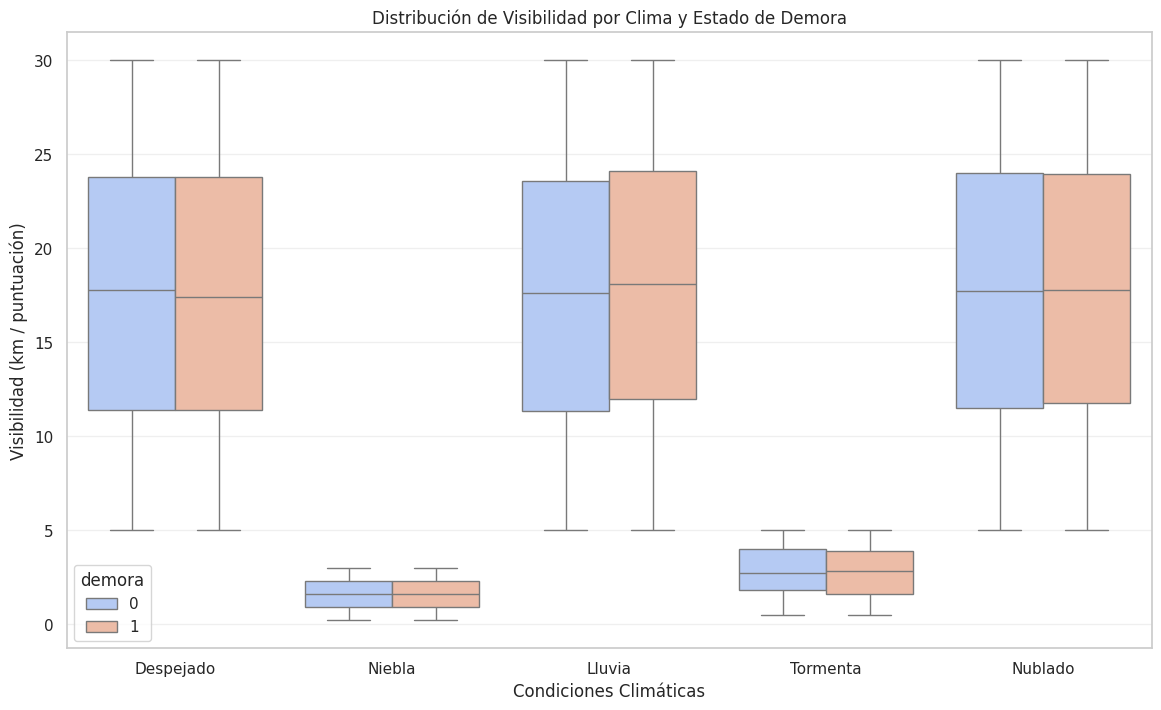

In [ ]:
### Clima vs Visibilidad para identificar demora

# Configuramos el tamaño y estilo
plt.figure(figsize=(14, 8))

# Creamos el Boxplot
# x: Clima (Categoría 1)
# y: Visibilidad (Numérica)
# hue: Demora (Objetivo)
sns.boxplot(
    x='condiciones_climaticas',
    y='visibilidad',
    hue='demora',
    data=df,
    palette='coolwarm'
)

plt.title('Distribución de Visibilidad por Clima y Estado de Demora')
plt.xlabel('Condiciones Climáticas')
plt.ylabel('Visibilidad (km / puntuación)')
plt.grid(axis='y', alpha=0.3)
plt.show()

El análisis de Boxplot revela que la visibilidad solo es un factor determinante de demora en condiciones de Niebla y Tormenta, donde los valores son consistentemente inferiores a 5 unidades. En condiciones de Despejado, Lluvia o Nublado, la visibilidad de los vuelos demorados es estadísticamente similar a la de los vuelos puntuales, lo que desplaza la causalidad hacia factores logísticos como la congestión aérea.

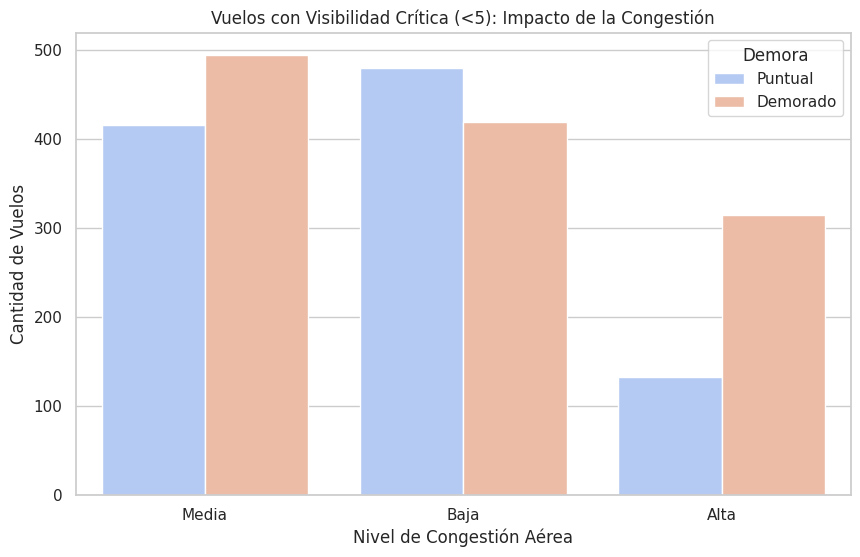

In [ ]:
### Visibilidad baja vs congestion aerea para identificar casos de demora exacta

# 1. Filtramos: Solo casos de visibilidad crítica (el "fondo" de tus cajas de tormenta)
df_critico = df[df['visibilidad'] <= 5]

# 2. Graficamos la cantidad de vuelos por Congestión, viendo cuántos se demoraron
plt.figure(figsize=(10, 6))
sns.countplot(x='congestion_aerea', hue='demora', data=df_critico, palette='coolwarm')

plt.title('Vuelos con Visibilidad Crítica (<5): Impacto de la Congestión')
plt.xlabel('Nivel de Congestión Aérea')
plt.ylabel('Cantidad de Vuelos')
plt.legend(title='Demora', labels=['Puntual', 'Demorado'])
plt.show()

Comparativa que identifica la interacción entre el factor ambiental y el logístico. Se evidencia que la congestión alta actúa como el detonante final de la demora cuando la visibilidad ya es deficiente, con una tasa de retraso sustancialmente mayor que en aeropuertos con baja densidad de tráfico.

## Imputacion de columnas que no aportan informacion (Excel vuelos)

---


Se eliminan columnas como id_vuelo,dia_semana, puerta_embarque, tiempo_estimado,tipo_avion, aeropuerto_origen, aeropuerto_destino

In [ ]:
df = df.drop(columns=['id_vuelo', 'dia_semana','distancia_vuelo', 'puerta_embarque','tiempo_estimado_vuelo','tipo_avion','aeropuerto_origen','aeropuerto_destino'])
df.head()

,hora_salida_programada,condiciones_climaticas,congestion_aerea,ocupacion_vuelo,temporada_alta,visibilidad,demora
0,09:30,Despejado,Baja,52.8,False,12.2,1
1,11:00,Despejado,Alta,54.4,True,10.7,1
2,08:15,Niebla,Media,48.7,True,1.0,0
3,06:45,Despejado,Baja,68.0,False,15.8,1
4,11:30,Despejado,Baja,92.0,True,23.0,0


## Transformacion de los datos restantes

### Transformacion de horario de salida a formato 0-23

In [ ]:
df['hora_salida_programada'] = df['hora_salida_programada'].astype(str).str.extract('(\d+)').astype(int)

# Verificamos que ahora el tipo de dato sea int64
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3948/3172739316.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['hora_salida_programada'] = df['hora_salida_programada'].astype(str).str.extract('(\d+)').astype(int)


,hora_salida_programada,condiciones_climaticas,congestion_aerea,ocupacion_vuelo,temporada_alta,visibilidad,demora
0,9,Despejado,Baja,52.8,False,12.2,1
1,11,Despejado,Alta,54.4,True,10.7,1
2,8,Niebla,Media,48.7,True,1.0,0
3,6,Despejado,Baja,68.0,False,15.8,1
4,11,Despejado,Baja,92.0,True,23.0,0


### Transformacion de demas valores
    - congestion_aerea (Baja(0)-Media(1)-Alta(2))
    - condiciones_climaticas (Creacion de columnas para cada tipo con valor binario)
    - temporada_alta de boolean a binaria

In [ ]:
# 1. Para Congestión (Ordinal): Definimos el orden manualmente
mapping_congestion = {'Baja': 0, 'Media': 1, 'Alta': 2}
df['congestion_aerea'] = df['congestion_aerea'].map(mapping_congestion)

# 2. Para Clima (One-Hot): Creamos las columnas automáticas
# El prefijo ayuda a mantener el orden en el dataframe
df = pd.get_dummies(df, columns=['condiciones_climaticas'], prefix='clima')

#Transformar todo lo boolean en binario (los climas y temporada_alta)
df = df.astype(int)

print(df.head())

   hora_salida_programada  congestion_aerea  ocupacion_vuelo  temporada_alta  \
0                       9                 0               52               0   
1                      11                 2               54               1   
2                       8                 1               48               1   
3                       6                 0               68               0   
4                      11                 0               92               1   

   visibilidad  demora  clima_Despejado  clima_Lluvia  clima_Niebla  \
0           12       1                1             0             0   
1           10       1                1             0             0   
2            1       0                0             0             1   
3           15       1                1             0             0   
4           23       0                1             0             0   

   clima_Nublado  clima_Tormenta  
0              0               0  
1              0      

## Modelo de arbol de decision

--- MÉTRICAS DEL MODELO ---
Precisión General (Accuracy): 0.66

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.69      0.74      2038
           1       0.48      0.61      0.54       962

    accuracy                           0.66      3000
   macro avg       0.64      0.65      0.64      3000
weighted avg       0.69      0.66      0.67      3000



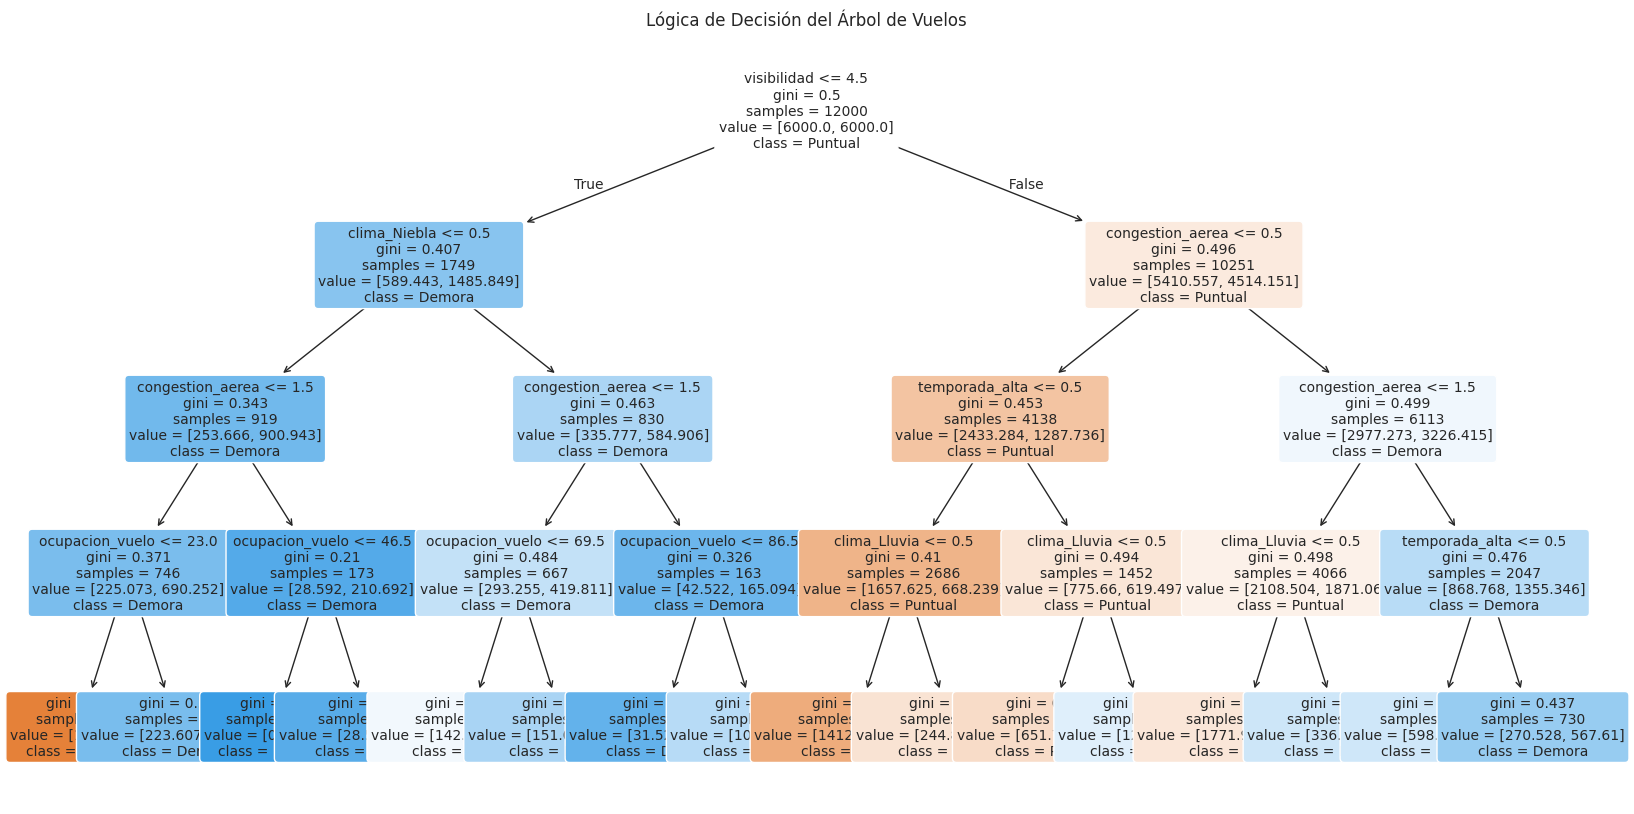

In [ ]:

# 1. Separación de características (X) y objetivo (y)
X = df.drop('demora', axis=1)
y = df['demora']

# 2. División en Train (80%) y Test (20%)
# Usamos random_state para que los resultados sean siempre iguales al repetir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación y entrenamiento del modelo
# Limitamos max_depth para que el gráfico sea legible y no se "sobreajuste"
modelo_arbol = DecisionTreeClassifier(max_depth=4, class_weight='balanced',random_state=42)
modelo_arbol.fit(X_train, y_train)

# 4. Predicciones
y_pred = modelo_arbol.predict(X_test)

# 5. Medidas de desempeño
print("--- MÉTRICAS DEL MODELO ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# 6. Visualización del Árbol
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol,
          feature_names=X.columns,
          class_names=['Puntual', 'Demora'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Lógica de Decisión del Árbol de Vuelos")
plt.show()

## Modelo KNN (vecino mas cercano)

In [ ]:

# 1. Escalado (Crucial para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenar KNN
for k in range(1,12):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)

  # 3. Predecir y evaluar
  y_pred_knn = knn.predict(X_test_scaled)
  print("--- MÉTRICAS DE KNN--- k=",k)
  print(classification_report(y_test, y_pred_knn))

--- MÉTRICAS DE KNN--- k= 1
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      2038
           1       0.36      0.35      0.35       962

    accuracy                           0.59      3000
   macro avg       0.53      0.53      0.53      3000
weighted avg       0.59      0.59      0.59      3000

--- MÉTRICAS DE KNN--- k= 2
              precision    recall  f1-score   support

           0       0.69      0.90      0.78      2038
           1       0.43      0.16      0.23       962

    accuracy                           0.66      3000
   macro avg       0.56      0.53      0.51      3000
weighted avg       0.61      0.66      0.61      3000

--- MÉTRICAS DE KNN--- k= 3
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      2038
           1       0.43      0.35      0.38       962

    accuracy                           0.65      3000
   macro avg       0.58      0.57      0.57 

In [ ]:
#1. Volvemos a generar el knn con el k que mejor predijo
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# 2. Generamos la matriz
cm = confusion_matrix(y_test, y_pred_knn)

# 3. La visualizamos de forma profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Puntual (0)', 'Demora (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Modelo KNN')
plt.show()

: 

# Prediccion de datos nuevos